#### Combined Analysis — Pre vs Post War


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent.parent))
from config import raw_data, control_data, external_data, raw_kyiv, filtered_data, daily_data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from functools import reduce
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc
from sklearn.base import clone
from sklearn.metrics import f1_score


import warnings
warnings.filterwarnings('ignore')


In [3]:
war_date = pd.to_datetime('2022-02-24')
pre_start = war_date - pd.DateOffset(months=6)
post_end = war_date + pd.DateOffset(months=6)

In [4]:
exclude = [
    '06b923ca-4d2d-44bb-8b20-4e2c9b08ce9f',
    '179bbc95-ec8b-4a65-98c5-5d3b566806fa'
]

In [5]:
cv_folds = 10

#### Features

In [6]:
features = [
    # activity sent
    'donor_daily_message_count',
    'donor_daily_avg_length',
    'donor_daily_audio_count',
    'daily_active_chats',
    'donor_daily_active_hours',
    # activity received
    'n_messages_received',
    # ratio
    'words_sent_over_words_received',
    # public activity 
    'donor_daily_post_count',
    'donor_daily_comment_count',
    'donor_daily_reaction_count',
    # temporal patterns
    'night_share',
    'night_share_reactions',
    # social structure
    'frac_words_closest_5_contacts',
]

In [7]:
base = daily_data

dfs_to_load = [
    'donor_daily_message_count.csv',
    'daily_active_chats.csv',
    'donor_daily_audio.csv',
    'donor_daily_posts.csv',
    'donor_daily_time_shares.csv',
    'donor_daily_avg_length.csv',
    'donor_daily_comments.csv',
    'donor_daily_reactions.csv',
    'donor_daily_active_hours.csv',
    'donor_daily_words_received.csv',
    'donor_daily_word_count.csv',
    'donor_daily_night_share_reactions.csv',
    'donor_daily_frac_words_top5.csv',
    'donor_daily_messages_received.csv'
]

loaded = [pd.read_csv(base / f) for f in dfs_to_load]
for d in loaded:
    d['date'] = pd.to_datetime(d['date'])

df_raw = reduce(
    lambda l, r: pd.merge(l, r, on=['donation_id', 'date'], how='outer'),
    loaded
).fillna(0)

df_raw['words_sent_over_words_received'] = (
    df_raw['donor_daily_word_count'] / (df_raw['words_received'] + 1e-9)
)

df_raw = df_raw[~df_raw['donation_id'].isin(exclude)]

In [8]:
df_raw = df_raw[
    (df_raw['date'] >= pre_start) & (df_raw['date'] <= post_end)
]

print(f'Donors: {df_raw["donation_id"].nunique()}')
print(f'Rows: {len(df_raw):,}')

Donors: 22
Rows: 7,512


In [9]:
df_raw['label'] = (df_raw['date'] >= war_date).astype(int)

print(f'Raw rows: {len(df_raw):,}')
print(f'Donors: {df_raw["donation_id"].nunique()}')
print(f'Pre-war days: {df_raw[df_raw["label"]==0]["date"].nunique()}')
print(f'Post-war days: {df_raw[df_raw["label"]==1]["date"].nunique()}')


Raw rows: 7,512
Donors: 22
Pre-war days: 184
Post-war days: 182


#### Models

In [10]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Linear SVM': LinearSVC(max_iter=2000, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
}

Days are shuffled and split using StratifiedKFold.

Within each fold, features are standardized per donor using StandardScaler: mean and standard deviation are computed on the training dates only and applied to the test dates. 
 
Daily values are then averaged across donors, so that each row represents one day across the full cohort.

In [11]:
def prepare_fold(df_raw, train_dates, test_dates, features):
    train_raw = df_raw[df_raw['date'].isin(train_dates)].copy()
    test_raw = df_raw[df_raw['date'].isin(test_dates)].copy()
    train_z = train_raw.copy()
    test_z = test_raw.copy()

    for donor_id in df_raw['donation_id'].unique():
        mask_train = train_raw['donation_id'] == donor_id
        mask_test = test_raw['donation_id']  == donor_id
        if mask_train.sum() == 0:
            continue
        donor_scaler = StandardScaler()
        train_z.loc[mask_train, features] = donor_scaler.fit_transform(
            train_raw.loc[mask_train, features]
        )
        if mask_test.sum() > 0:
            test_z.loc[mask_test, features] = donor_scaler.transform(
                test_raw.loc[mask_test, features]
            )

    train_avg = train_z.groupby('date')[features + ['label']].mean().reset_index()
    test_avg = test_z.groupby('date')[features + ['label']].mean().reset_index()

    X_train = train_avg[features].values
    y_train = (train_avg['label'] >= 0.5).astype(int).values
    X_test = test_avg[features].values
    y_test = (test_avg['label'] >= 0.5).astype(int).values
    return X_train, y_train, X_test, y_test


outer_cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

date_labels = df_raw.groupby('date')['label'].first().reset_index()
date_labels = date_labels.sample(frac=1, random_state=42).reset_index(drop=True)
all_dates_arr = date_labels['date'].values
all_labels_arr = date_labels['label'].values

cv_results = {m: [] for m in models}
cv_results_f1 = {m: [] for m in models}
y_scores = {m: np.zeros(len(all_dates_arr)) for m in models}
y_true_all = np.zeros(len(all_dates_arr))

for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(all_dates_arr, all_labels_arr)):
    train_dates = set(all_dates_arr[train_idx])
    test_dates = set(all_dates_arr[test_idx])

    X_train, y_train, X_test, y_test = prepare_fold(
        df_raw, train_dates, test_dates, features
    )
    y_true_all[test_idx] = y_test

    for model_name, model in models.items():
        clf = clone(model)
        clf.fit(X_train, y_train)

        preds = clf.predict(X_test)
        cv_results[model_name].append((preds == y_test).mean())
        cv_results_f1[model_name].append(f1_score(y_test, preds))

        if hasattr(clf, 'decision_function'):
            scores = clf.decision_function(X_test)
        else:
            scores = clf.predict_proba(X_test)[:, 1]
        y_scores[model_name][test_idx] = scores

In [12]:
summary = pd.DataFrame({
    'Model': list(cv_results.keys()),
    'Mean Accuracy': [np.mean(v).round(3) for v in cv_results.values()],
    'Std Accuracy': [np.std(v).round(3)  for v in cv_results.values()],
    'Mean F1': [np.mean(v).round(3) for v in cv_results_f1.values()],
    'Std F1': [np.std(v).round(3)  for v in cv_results_f1.values()],
}).set_index('Model')
display(summary)

,Mean Accuracy,Std Accuracy,Mean F1,Std F1
Model,,,,
Logistic Regression,0.708,0.071,0.691,0.072
Random Forest,0.721,0.054,0.714,0.047
Linear SVM,0.702,0.059,0.679,0.068
Gradient Boosting,0.691,0.052,0.690,0.055


#### ROC сurve


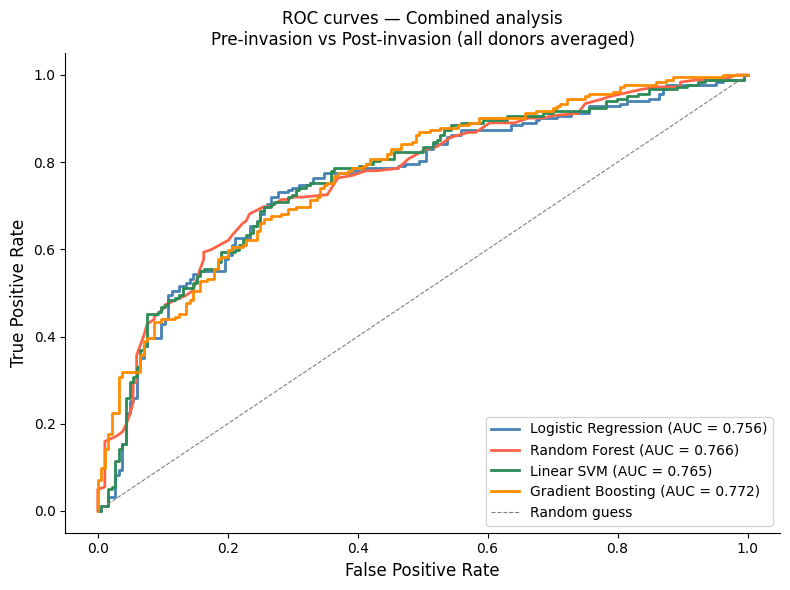

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['steelblue', 'tomato', 'seagreen', 'darkorange']

for model_name, color in zip(models.keys(), colors):
    fpr, tpr, _ = roc_curve(y_true_all, y_scores[model_name])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{model_name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], color='gray', linewidth=0.8,
        linestyle='--', label='Random guess')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC curves — Combined analysis\n'
             'Pre-invasion vs Post-invasion (all donors averaged)',
             fontsize=12)
ax.legend(fontsize=10, loc='lower right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


In [14]:
auc_scores = {}
for model_name in models.keys():
    fpr, tpr, _ = roc_curve(y_true_all, y_scores[model_name])
    auc_scores[model_name] = round(auc(fpr, tpr), 3)

summary['AUC'] = pd.Series(auc_scores)
display(summary)

,Mean Accuracy,Std Accuracy,Mean F1,Std F1,AUC
Model,,,,,
Logistic Regression,0.708,0.071,0.691,0.072,0.756
Random Forest,0.721,0.054,0.714,0.047,0.766
Linear SVM,0.702,0.059,0.679,0.068,0.765
Gradient Boosting,0.691,0.052,0.690,0.055,0.772


#### Feature importance 

In [15]:
df_z_full = df_raw.copy()
for donor_id in df_raw['donation_id'].unique():
    mask = df_raw['donation_id'] == donor_id
    df_z_full.loc[mask, features] = StandardScaler().fit_transform(
        df_raw.loc[mask, features]
    )

day_avg_full = df_z_full.groupby('date')[features + ['label']].mean().reset_index()
X_full = day_avg_full[features].values
y_full = (day_avg_full['label'] >= 0.5).astype(int).values

importances = {}
models_fitted = {}

for model_name, model in models.items():
    clf_full = clone(model)
    clf_full.fit(X_full, y_full)
    models_fitted[model_name] = clf_full

    if hasattr(clf_full, 'coef_'):
        imp = np.abs(clf_full.coef_[0])
    elif hasattr(clf_full, 'feature_importances_'):
        imp = clf_full.feature_importances_
    else:
        imp = np.zeros(len(features))
    imp = imp / (imp.sum() + 1e-9)
    importances[model_name] = imp

imp_df = pd.DataFrame(importances, index=features)


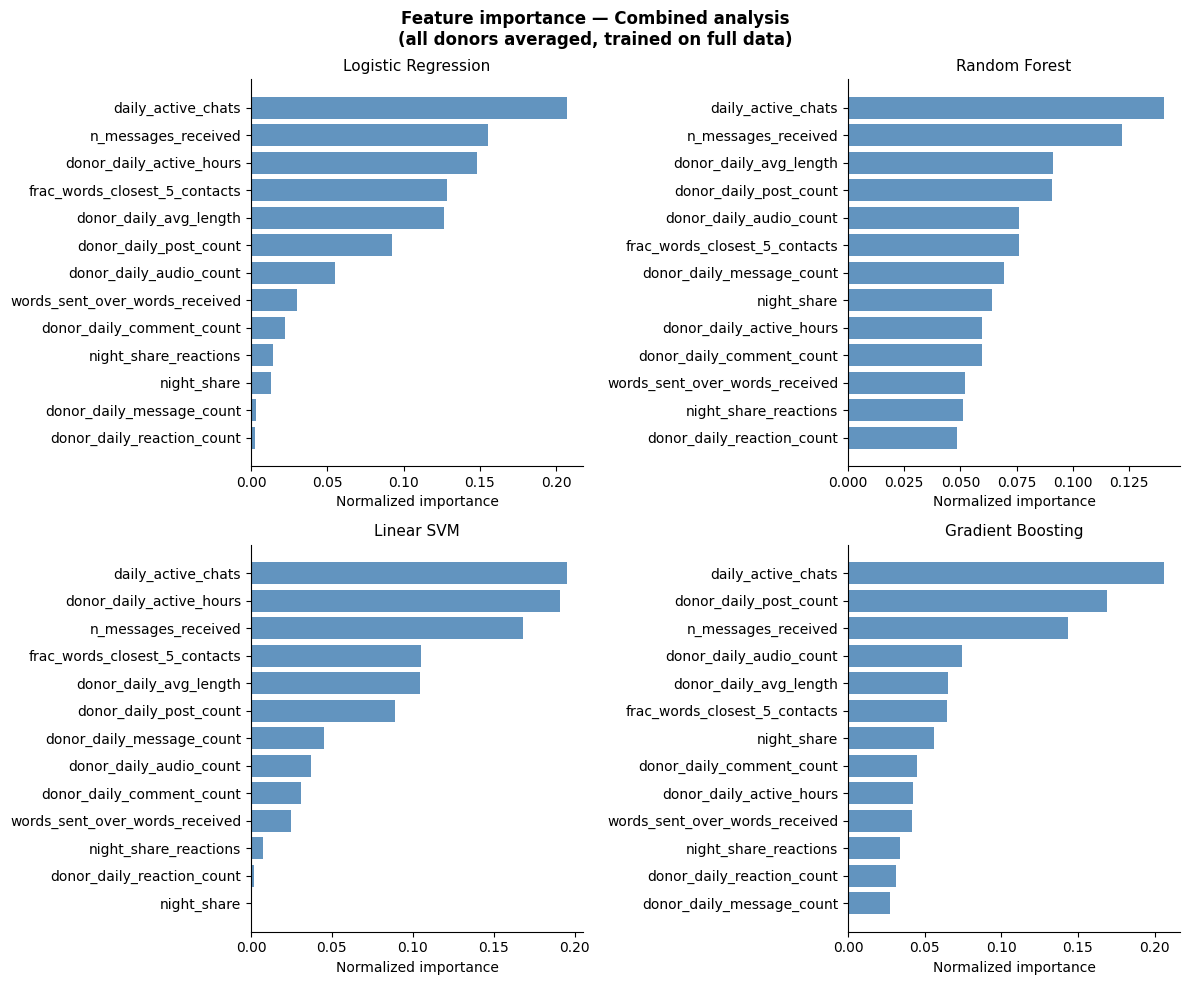

In [16]:
n_cols = 2
n_rows = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 10))
axes = axes.flatten()

for ax, model_name in zip(axes, models.keys()):
    imp = imp_df[model_name].sort_values()
    ax.barh(imp.index, imp.values, color='steelblue', alpha=0.85)
    ax.set_xlabel('Normalized importance', fontsize=10)
    ax.set_title(model_name, fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Feature importance — Combined analysis\n'
             '(all donors averaged, trained on full data)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()